In [15]:
using LinearAlgebra
using DelimitedFiles
using Tullio 
### 
using PyPlot
const plt = PyPlot
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text

# 1D systems

In [16]:
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1]) 
σ_x =  Matrix{ComplexF64}([0 1; 1 0]) 
σ_y =  Matrix{ComplexF64}([0 -im ; im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])
# ## Calculation of the tranmission 
# ny,nx=3,3
# η = 1e-4
# One = Diagonal(ones(nx*ny*2)) 
# SL = zeros(ComplexF64,nx,nx)
# SL[1,1] = 1.
# SR = zeros(ComplexF64,nx,nx)
# SR[end,end] = 1.
# ######----- system parameters--------
# γ,γso,Bz,ny,nx = 1,1,0,ny,nx
# HC = Central_H(γ,γso,Bz,nx,ny)
# G0c(E) = inv((E+1im*η)*One-HC) 
# ######----- Lead parameters--------
# γ,γso,Bz,ny = 1,1,0,ny
# H0,T = Block_H(γ,γso,Bz,ny)
# #### Hamiltonians
# ΓL(E) = 1im*(Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η) - Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η)' )
# ΓR(E) = 1im*(Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η) - Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)' )
# ΣT(E) = SL⊗Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η) + SR⊗Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)
# Gc(E) = inv((E+1im*η)*One-HC-ΣT(E)) 
# ######----- Transmission--------
# Tra(E) = tr(ΓR(E)*Gc(E)[end-2ny+1:end,1:2ny]*ΓL(E)*(Gc(E)[end-2ny+1:end,1:2ny])' )

2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im

## Selfenergy 

### Analitycal self energy

In [17]:
# Exact selfenergy 
function selfenergy(energy)#, global_var)
    ### Note that this configuration for the self energy can be modified later
    # thop = global_var.thop
    thop = 1
    t_ls = 1.
    rad = 4 * thop^2 - energy^2
    if real(rad) > 0
        selfenergy = energy - im * sqrt(rad)
    else
        if real(energy) > 0
            sgn = 1
        else
            sgn = -1
        end
        selfenergy = energy - sgn * sqrt(-rad)
    end
    selfenergy = selfenergy * (thop^2 / (2 * t_ls^2))
    return selfenergy
end

selfenergy (generic function with 1 method)

### Computational Selfenergy

In [18]:
function Selfenergy(;E,H0l,H1l,Hlc,eta, epsilon=1e-10)
    "Calculation of the selfenergy. 
    The parameters needed are
    H0L : Supercell
    HLC: Matrix connecting the central system with the leads
    H1L : Hopping between super cells"
    one = Diagonal(ones(size(H0l)[1]))
    A0 = H1l'
    B0 = H1l
    C0 = (E + 1im*eta)*one - H0l
    D0 = (E +1im*eta)*one - H0l
    invD0 = inv(D0)
    while norm(A0) > epsilon
        #println(1)
        C = C0 - A0*invD0*B0
        D = D0 - A0*invD0*B0 - B0*invD0*A0
        A = A0*invD0*A0
        B = B0*invD0*B0
        ###################################
        A0 = A
        B0 = B
        C0 = C
        D0 = D
        invD0 =inv(D0)
    end
    g_L = inv(C0) ### Surface green function of the lead 
    Self = Hlc'*g_L*Hlc
end
### Computational checks
### Kron product
⊗(A,B) = kron(A,B)
### Block Hamiltonian 
function Block_H(γ,γso,Bz,ny)
    dim = ny*2 # We include the spin degree of freedom 
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' -Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end
### Central Hamiltonian
function Central_H(γ,γso,Bz,nx,ny)
    dim = nx*ny*2
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = Block_H(γ,γso,Bz,ny)
    Tx = diagm( -1 =>  ones(nx-1))⊗T #, 1 =>  ones(nx-1))
    HC = (One_x⊗H0) +  Tx + Tx'
    return HC
end
### Transmission
function Transmission(E,γ,γso,Bz,nx,ny;η=1e-4)
    One = Diagonal(ones(nx*ny*2)) 
    SL = zeros(ComplexF64,nx,nx)
    SL[1,1] = 1.
    SR = zeros(ComplexF64,nx,nx)
    SR[end,end] = 1.
    ######----- system parameters--------
    HC = Central_H(γ,γso,Bz,nx,ny)
    #G0c(E) = inv((E+1im*η)*One-HC) 
    ######----- Lead parameters--------
    H0,T = Block_H(γ,γso,Bz,ny)
    #### Hamiltonians
    ΓL(E) = 1im*(Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η) - Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η)' )
    ΓR(E) = 1im*(Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η) - Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)' )
    ΣT(E) = SL⊗Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η) + SR⊗Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)
    ######----- Effectiv GF--------
    Gc(E) = inv((E+1im*η)*One-HC-ΣT(E)) 
    return tr(ΓR(E)*Gc(E)[end-2ny+1:end,1:2ny]*ΓL(E)*(Gc(E)[end-2ny+1:end,1:2ny])' )
end
# nx,ny=3,3
# γ,γso,Bz,ny,nx = 1,0,0,ny,nx
# T0(E)=Transmission(E,1,0,0,nx,ny;η=1e-4)
# γ,γso,Bz,ny,nx = 1,1,0,ny,nx
# T1(E)=Transmission(E,1,1,0,nx,ny;η=1e-4)
# es = -6:0.1:6
# plt.plot(es,T0.(es) )
# plt.plot(es,T1.(es) )

Transmission (generic function with 1 method)

In [19]:
# γ,γso,Bz,nx,ny = 1,1,0,3,3
# H0,T = Block_H(γ,γso,Bz,ny)
# ΣT(E) = SL⊗Selfenergy(E=E,H0l=H0,H1l=T',Hlc=T',eta=η) + SR⊗Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)
# HC = Central_H(γ,γso,Bz,nx,ny)
# ######----- Effectiv GF--------
# Gc(E) = inv((E+1im*η)*One-HC-ΣT(E)) 
# imshow(real.(Gc(0)))
# plt.ylim(0,17.5)

In [20]:
# HC = Central_H(1,1,0,3,3)
# imshow(imag.(HC))
# imshow(real.(Gc(0.0)))
# plt.ylim(0,17.5)
using DelimitedFiles
using CSV
using DataFrames

# CSV.write("G0.csv", DataFrame(Gc(0.0),:auto))
# CSV.write("G05.csv", DataFrame(Gc(0.5),:auto))
# CSV.write("H.csv", DataFrame(HC,:auto))
# nx,ny=3,3
# γ,γso,Bz,ny,nx = 1,0,0,ny,nx
# T0(E)=Transmission(E,1,0,0,nx,ny;η=1e-4)
# γ,γso,Bz,ny,nx = 1,1,0,ny,nx
# T1(E)=Transmission(E,1,1,0,nx,ny;η=1e-4)
# es = -6:0.1:6
# plt.plot(es,T0.(es) )
# plt.plot(es,T1.(es) )

In [21]:
#diagm( 11 =>  ones(nx-1))

In [28]:
γ,γso,Bz,ny,nx = 1,0,0,1,2
H0,T = Block_H(γ,γso,Bz,ny)
S1(E)=real(tr(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-4, epsilon=1e-10)))
S2(E)=imag(tr(Selfenergy(;E=E,H0l=H0,H1l=T,Hlc=T,eta=1e-4, epsilon=1e-10)))

S2 (generic function with 1 method)

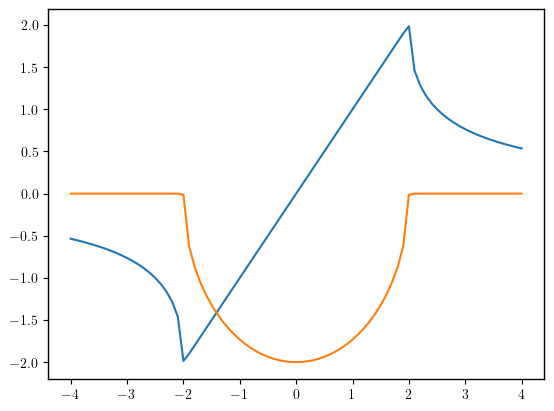

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f4a331b3dd0>

In [29]:
Es=-4:0.1:4
plt.plot(Es,S1.(Es))
plt.plot(Es,S2.(Es))

### Lorentzian fitting

In [280]:
#using Pkg
#Pkg.add("LsqFit") 

In [41]:
using LsqFit

function lorentz_sum(ω, p)
    Λ, W, ϵ0 = p  # p is a tuple of three vectors
    N = length(Λ)
    y = zeros(length(ω))
    #y = sum(Λ.*W.^2 ./((ω .- ϵ0).^2 .+ W.^2))
    #y .+= Λ[i] * W[i] ./ ((ω .- ϵ0[i]).^2 .+ W[i]^2)
    for i in 1:N
        y .+= Λ[i] * W[i]^2 ./ ((ω .- ϵ0[i]).^2 .+ W[i]^2)
    end
    
    return y
end
# Wrapper to reshape flat parameter vector into (Λ, W, ϵ0)
function unpack(p::AbstractVector)
    N = div(length(p), 3)
    Λ = p[1:N]
    W = p[N+1:2N]
    ϵ0 = p[2N+1:3N]
    return Λ, W, ϵ0
end
# This function is compatible with LsqFit
function model(ω, p)
    lorentz_sum(ω,unpack(p))
end

# xdata = range(-10, 10, length=100)
# # Here the number of lorentzians are determined
# Λ_true = [1.5, 2.0]
# W_true = [1.0, 0.5]
# ϵ0_true = [-2.0, 2.0]
# ydata = lorentz_sum(xdata,p0)
# p0 = [1.0, 1.0,  0.8, 0.8,  -1.0, 1.0]
# fit = curve_fit(model, xdata, ydata, p0) ;
# ###
# Λ_fit, W_fit, ϵ0_fit = unpack(fit.param) ;
# plt.plot(xdata, ydata, label="Data")
# plt.plot(xdata, lorentz_sum(xdata, (Λ_fit, W_fit, ϵ0_fit)), label="Fit",ls = "--")

model (generic function with 1 method)

In [43]:
# γ,γso,Bz,ny,nx = 1,1,0,1,1
# H0,T = Block_H(γ,γso,Bz,ny)
#Self(E) = Selfenergy(E=E,H0l=H0,H1l=T,Hlc=T,eta=η)
xdata = -2:0.01:2 
ydata = -2imag(selfenergy.(xdata))


N = 15
Λ_1 = rand(N)#gam_R[:,1]
W_1= rand(N)#w0_R
ϵ0_1= rand(N)#eps_R;

p0 = vcat(Λ_1, W_1, ϵ0_1)
fit = curve_fit(model, xdata, ydata, p0) ;
#Λ_fit, W_fit, ϵ0_fit = unpack(fit.param) ;
#ϵs, -2imag(selfenergy.(ϵs)),
#plt.plot(xdata,ydata)
#p0
#rand(30)

In [442]:
#

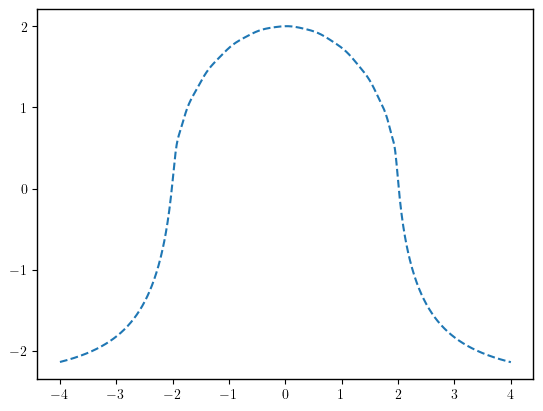

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fc3c8e47da0>

In [446]:
xdata = -4:0.01:4 
Λ_fit, W_fit, ϵ0_fit = unpack(fit.param) ;
#plt.plot(xdata, ydata, label="Data")
plt.plot(xdata, lorentz_sum(xdata, (Λ_fit, W_fit, ϵ0_fit)), label="Fit",ls = "--")

In [ ]:
using Optim

In [474]:
### Now the idea is to use constraints 
#using Pkg
#Pkg.add("Optim")
xdata = -2.5:0.01:2.5 
ydata = -2imag(selfenergy.(xdata))

function loss(p)
    model = lorentz_sum(xdata,unpack(p))
    return sum((model .- ydata).^2)
end

N = 40
Λ_1 = rand(N)#gam_R[:,1]
W_1= rand(N)*0.1#w0_R
ϵ0_1= rand(N)#eps_R;

p0 = vcat(Λ_1, W_1, ϵ0_1)

lowΛ = zeros(N)
lowW = -0.1*ones(N)
lowϵ = -2*ones(N)

uppΛ = 1*ones(N)
uppW = 0.1*ones(N)
uppϵ = 2*ones(N)

upΛ = ones(N)

lower = vcat(lowΛ,lowW, lowϵ)#[0.0, 0.0,  0.01, 0.01,  -10.0, -10.0]
upper = vcat(uppΛ,uppW, uppϵ)#[5.0, 5.0,  5.0, 5.0,     10.0,  10.0]

#fit = curve_fit(model, xdata, ydata, p0) ;

result = optimize(loss, lower, upper, p0, Fminbox(BFGS()))

 * Status: success

 * Candidate solution
    Final objective value:     1.045998e+00

 * Found with
    Algorithm:     Fminbox with BFGS

 * Convergence measures
    |x - x'|               = 3.35e-06 ≰ 0.0e+00
    |x - x'|/|x'|          = 3.68e-07 ≰ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 3.30e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   81  (vs limit Inf)
    Iterations:    4
    f(x) calls:    9144
    ∇f(x) calls:   9144


In [475]:
Λ, W, ϵ0 = unpack(Optim.minimizer(result))

([0.8126672169381229, 0.4629374930630109, 0.7927524040175006, 0.8042992430301524, 0.7948835180310824, 0.35561787701964537, 0.5831046301519841, 0.7106931958058511, 0.8042992430368106, 0.7704576843625557  …  0.8256148106070887, 0.5065120498852071, 0.819112217894793, 0.5462581358928142, 0.7704576843743725, 0.8234439626528316, 0.710693195791997, 0.6810825816851697, 0.5462581358959316, 0.4629374930575987], [0.09999999995133643, -0.0389936462143537, 0.09999999972361362, -0.09999999994150705, 0.09999999991731179, -0.02693545210863911, 0.05760054960963177, -0.08425415179208613, 0.09999999994151067, 0.09659728146546222  …  0.099999999960148, -0.04504776362237766, 0.09999999995634042, -0.05124059616184512, 0.0965972814671002, 0.09999999995898479, 0.08425415178899576, 0.07753744935966067, 0.051240596163176305, 0.03899364620912367], [-0.4302382742268846, 1.765403340995541, 0.8017317003701946, -0.5536396867381821, -0.6774012217356273, 1.8838269759082618, 1.5430741438690856, 1.1566113712959971, 0.55

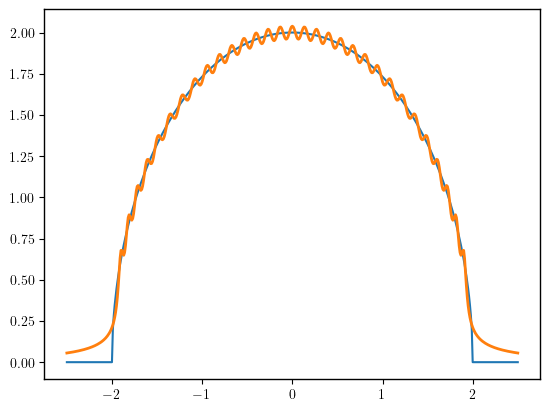

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fc3c1c23050>

In [469]:
plt.plot(xdata, ydata, label="Data")
plt.plot(xdata, lorentz_sum(xdata,(Λ, W, ϵ0)), label="Fit", lw=2)

In [434]:
### Other idea is use the Grand-Schidt decomposition 
using QuadGK
function lorentz(ω, ϵ, Γ)
    return (Γ ./ ((ω .- ϵ).^2 .+ Γ^2)) ./ π
end
function inner(f, g, a, b)
    return quadgk(ω -> f(ω) * g(ω), a, b)[1]
end
# Gram-Schmidt on a list of Lorentzians
function gram_schmidt_lorentzians(ϵs, Γs, a, b)
    N = length(ϵs)
    basis = Vector{Function}(undef, N)
    for j in 1:N
        Lj = ω -> lorentz(ω, ϵs[j], Γs[j])
        φj = Lj
        for k in 1:j-1
            proj_coeff = inner(Lj, basis[k], a, b) / inner(basis[k], basis[k], a, b)
            φk = basis[k]
            φj = ω -> φj(ω) - proj_coeff * φk(ω)
        end
        basis[j] = φj
    end
    return basis
end

In [36]:
n_channels = 2 ;
n_lorentz = 31 ;

In [44]:
data_fit_pdbest = readdlm( "./selfenergy/selfenergy_1DTB_NNLS_31_pbest.csv" , ',', Float64)
data_fit_Ulsq = readdlm( "./selfenergy/selfenergy_1DTB_NNLS_31_Ulsq.csv", ',', Float64) ;

In [45]:
eps_L = copy(data_fit_pdbest[1:2:end])                                ### Resonant level
eps_R = copy(eps_L)
w0_L  = abs.(data_fit_pdbest[2:2:end])                                ### Level witdth
w0_R  = copy(w0_L)
w0_k1α = cat(w0_L,w0_R,dims=2)                                        ### Tensor definition of the fitting parameters
eps_k1α = cat(eps_L,eps_R,dims=2)
gam_L = zeros(Float64, n_lorentz,n_channels)                          ### Gamma function
gam_R = zeros(Float64,n_lorentz,n_channels)
gam_L[:,1] = data_fit_Ulsq
gam_L[:,2] = data_fit_Ulsq
gam_R = copy(gam_L)
gam_k1iα = cat(gam_L,gam_R,dims=3) ;                                   ### Tensor definition of the gamma function 

In [46]:
Gamma(ϵ) = sum(gam_R[:,1].*w0_R.^2 ./((ϵ .- eps_R).^2 .+ w0_R.^2))

Gamma (generic function with 1 method)

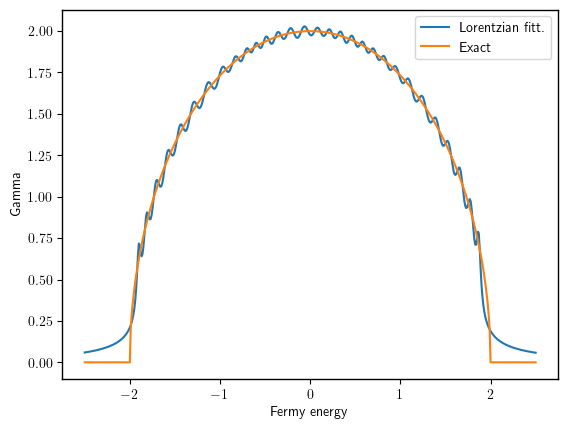

PyObject <matplotlib.legend.Legend object at 0x7f4a3311a870>

In [48]:
#eps_L
#Gamma(0.1)
ϵs = -2.5:0.01:2.5 
plt.plot(ϵs ,Gamma.(ϵs),label = "Lorentzian fitt.")
plt.plot(ϵs, -2imag(selfenergy.(ϵs)), label = "Exact" )
# plt.plot(ϵs, lorentz_sum(ϵs,(Λ, W, ϵ0)), label="Fit", lw=2)
plt.xlabel("Fermy energy ")
plt.ylabel("Gamma")
plt.legend()
#eps_L

# 2D systems